In [107]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [108]:
df=pd.read_csv('netflix1.csv')
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [109]:
print(df.columns)
df.shape

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')


(8790, 10)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [111]:
df.duplicated().sum()

np.int64(0)

In [112]:
np.isinf(df['release_year']).sum()

np.int64(0)

In [113]:
df['release_year'].describe()

count    8790.000000
mean     2014.183163
std         8.825466
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

In [114]:
df['show_id'].head(10)

0      s1
1      s3
2      s6
3     s14
4      s8
5      s9
6     s10
7    s939
8     s13
9    s940
Name: show_id, dtype: object

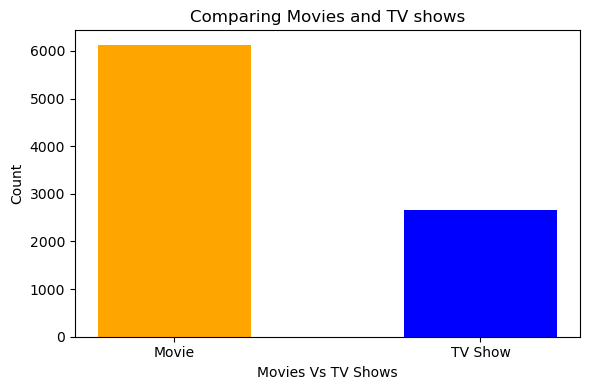

In [115]:
type_counts=df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index,type_counts.values,color=['orange','blue'],width=0.5)
plt.title('Comparing Movies and TV shows')
plt.xlabel('Movies Vs TV Shows')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('count_mTV.png',dpi=300,bbox_inches='tight')
plt.show()


In [116]:
val_counts=df['rating'].value_counts()
print(val_counts.index,val_counts.values)

Index(['TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13', 'TV-Y7', 'TV-Y', 'PG', 'TV-G',
       'NR', 'G', 'TV-Y7-FV', 'NC-17', 'UR'],
      dtype='object', name='rating') [3205 2157  861  799  490  333  306  287  220   79   41    6    3    3]


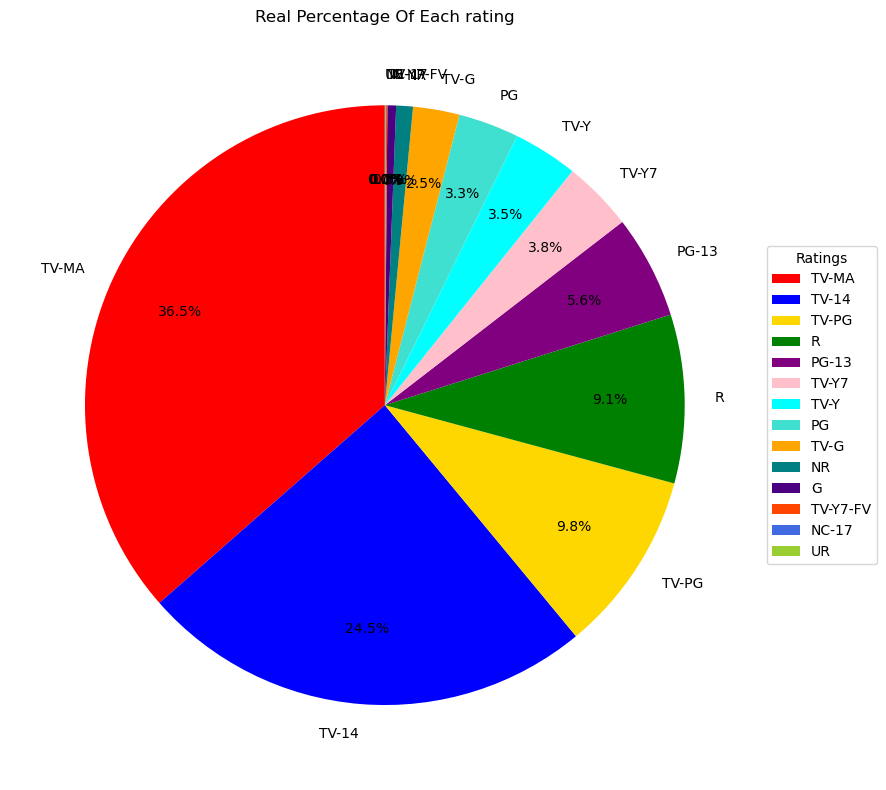

In [117]:
plt.figure(figsize=(10,8))
x=[3205,2157,861,799,490,333,306,287,220,79,41,6,3,3]
labels=val_counts.index
plt.pie(x,labels=labels,colors=['red', 'blue', 'gold', 'green',
 'purple', 'pink', 'cyan', 'turquoise',
 'orange', 'teal', 'indigo', 'orangered',
 'royalblue', 'yellowgreen'],autopct='%1.1f%%',pctdistance=0.75,startangle=90)
plt.legend(labels,
          title='Ratings',
           loc='center left',
          bbox_to_anchor=(1,0.5))
plt.title('Real Percentage Of Each rating')
plt.tight_layout()
plt.savefig('pieRating.png',dpi=300,bbox_inches='tight')
plt.show()


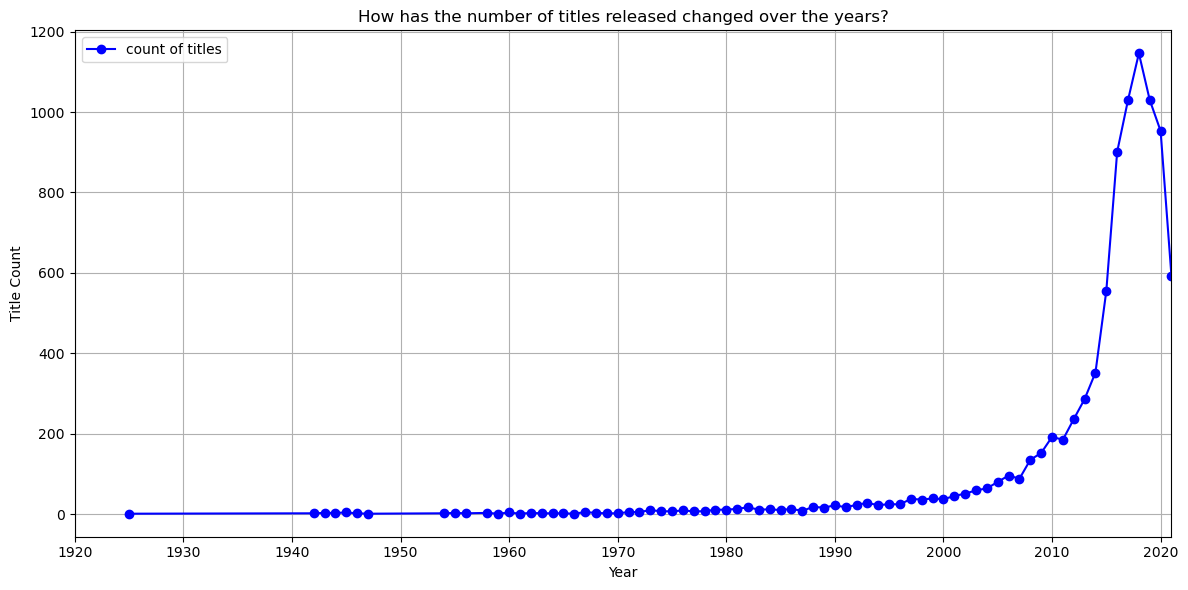

In [118]:
title_counts=df['release_year'].value_counts().sort_index()
plt.figure(figsize=(12,6))
plt.plot(title_counts.index,title_counts.values,color='blue',marker='o',label='count of titles')
plt.title('How has the number of titles released changed over the years?')
plt.xlabel('Year')
plt.ylabel('Title Count')
plt.xlim([1920,2021])
plt.xticks(range(1920,2022,10))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('title_count_year.png',dpi=300,bbox_inches='tight')
plt.show()

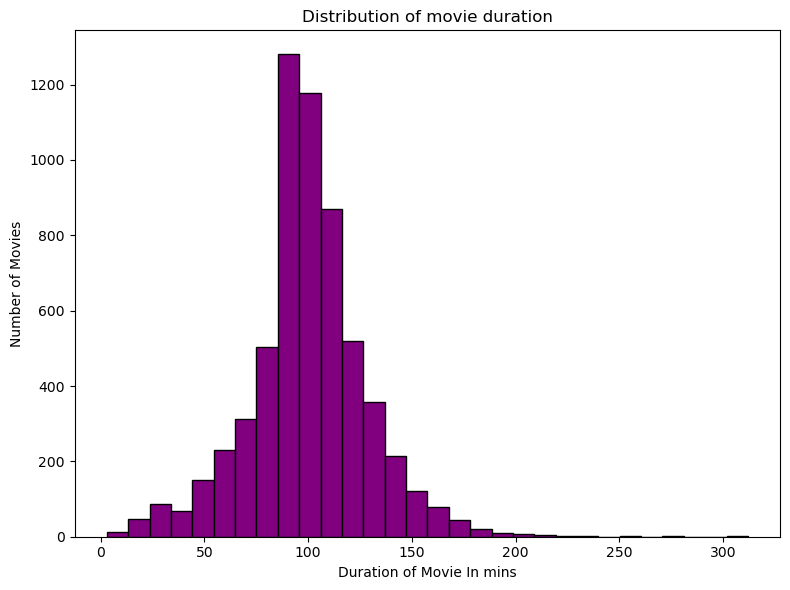

In [119]:
movie_df=df[df['type']=='Movie'].copy()
movie_df['duration_time']=movie_df['duration'].str.replace('min','').astype(int)
plt.figure(figsize=(8,6))
plt.hist(movie_df['duration_time'],bins=30,color='purple',edgecolor='black')
plt.title('Distribution of movie duration')
plt.xlabel('Duration of Movie In mins')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('Movie_duration_distribution.png',dpi=300,bbox_inches='tight')
plt.show()

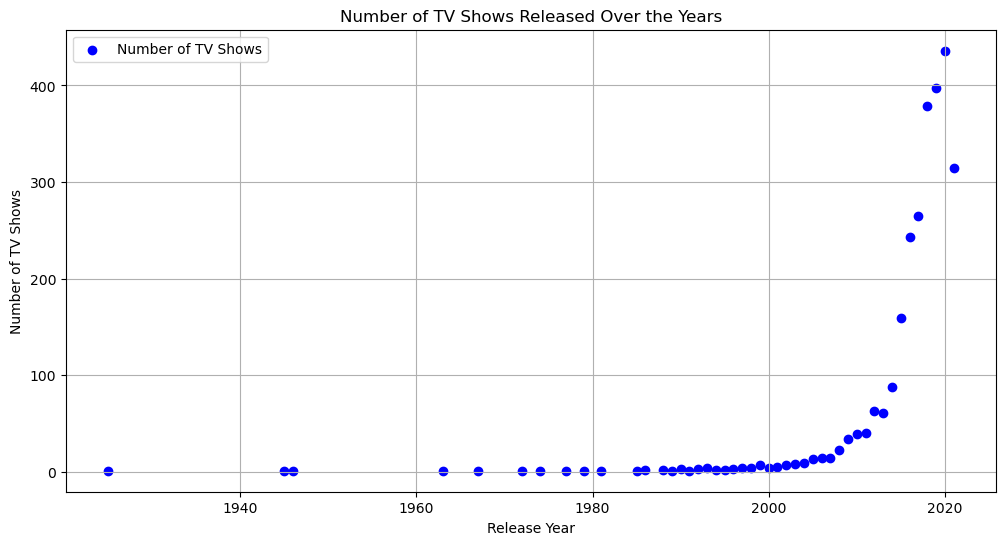

In [120]:
show_df=df[df['type']=='TV Show'].copy()
show_counts=show_df['release_year'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
plt.scatter(show_counts.index,show_counts.values,color='blue',marker='o',label='Number of TV Shows')
plt.title('Number of TV Shows Released Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Number of TV Shows')
plt.grid(True)
plt.legend()
plt.savefig('rel_year_show.png',dpi=300,bbox_inches='tight')
plt.show()

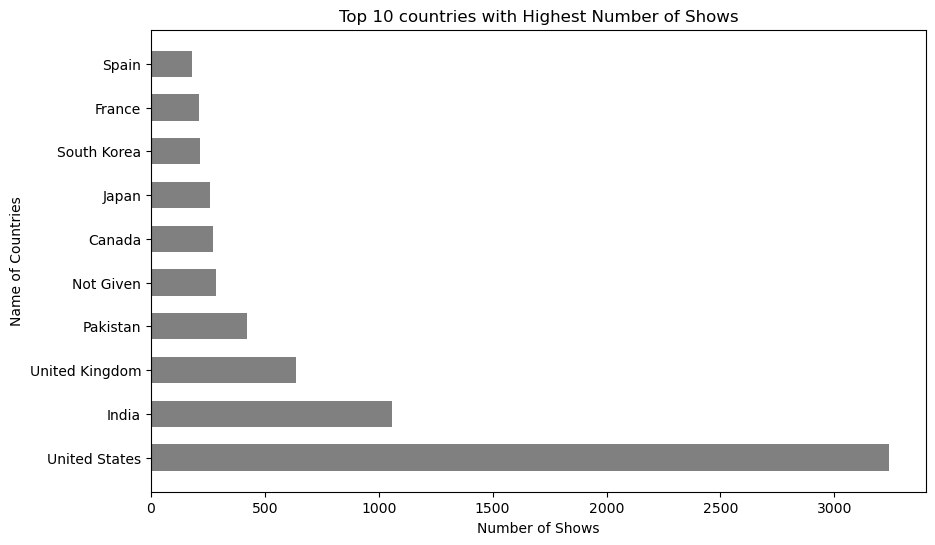

In [121]:
show_top10 =df['country'].value_counts().head(10)
plt.figure(figsize=(10,6))
plt.barh(show_top10.index,show_top10.values,height=0.6,color='grey')
plt.title('Top 10 countries with Highest Number of Shows')
plt.xlabel('Number of Shows')
plt.ylabel('Name of Countries')
plt.savefig('top_10_shows.png',dpi=300,bbox_inches='tight')
plt.show()

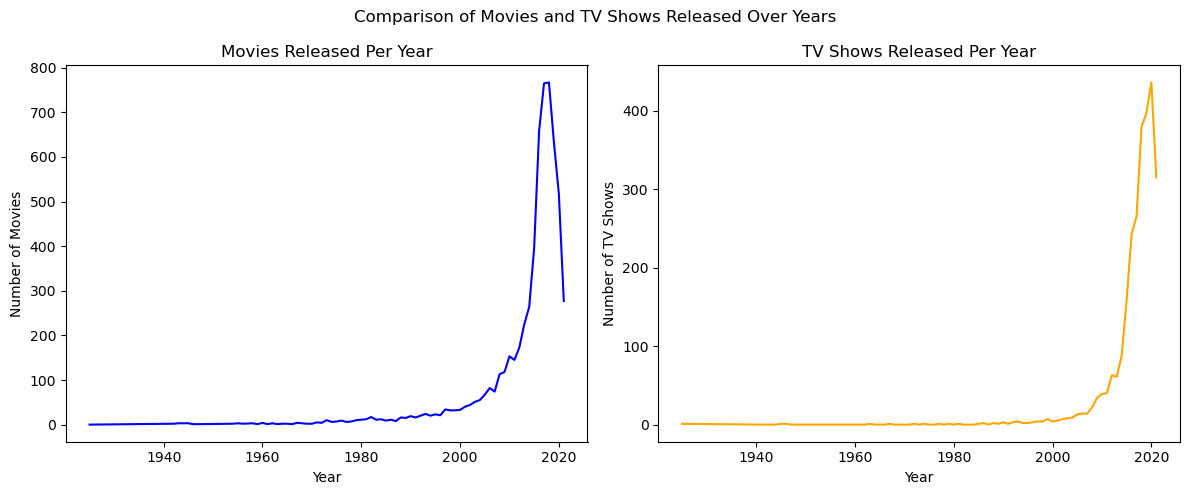

In [122]:
content_by_year =df.groupby(['release_year', 'type']).size().unstack().fillna(0)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(content_by_year.index,content_by_year['Movie'],color='blue')
ax[0].set_title('Movies Released Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')
ax[1].plot(content_by_year.index,content_by_year['TV Show'],color='orange')
ax[1].set_title('TV Shows Released Per Year')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Number of TV Shows')
fig.suptitle('Comparison of Movies and TV Shows Released Over Years')
fig.tight_layout()
fig.savefig('movies_tv_shows.png', dpi=300, bbox_inches='tight')
plt.show()

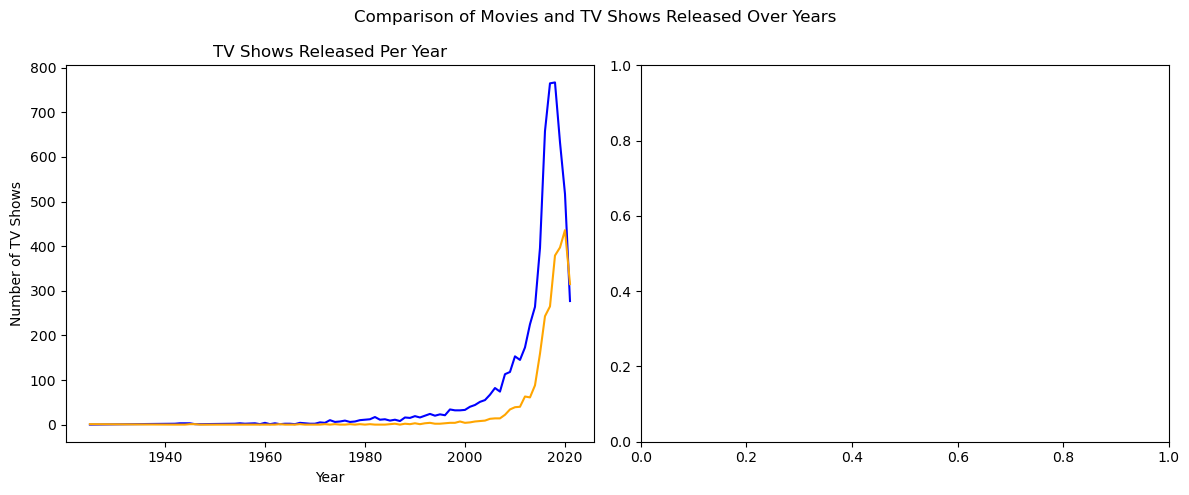

In [123]:
content_by_year =df.groupby(['release_year', 'type']).size().unstack().fillna(0)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(content_by_year.index,content_by_year['Movie'],color='blue')
ax[0].set_title('Movies Released Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')
ax[0].plot(content_by_year.index,content_by_year['TV Show'],color='orange')
ax[0].set_title('TV Shows Released Per Year')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of TV Shows')
fig.suptitle('Comparison of Movies and TV Shows Released Over Years')
fig.tight_layout()
fig.savefig('movies_tv_showss.png', dpi=300, bbox_inches='tight')
plt.show()